## Multiple Tools

In [1]:
# 1) Sequential tool calls
# 2) Parallel tool calls
# 3) No tool calls

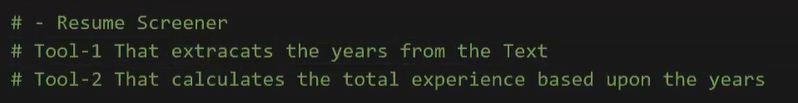

In [1]:
import os
import json
import re
from openai import OpenAI
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

### Step 1: Create Tool 1 (Extract Years)

In [3]:
def extract_years(text):
    years = re.findall(r'\b(19\d{2}|20\d{2})\b', text)
    return [int(i) for i in years]

In [4]:
extract_years_tool = {
    'type': 'function',
    'function': {
        'name': 'extract_years',
        'description': 'Extracts all dates given in the text and returns a Python list.',
        'parameters': {
            'type': 'object',
            'properties': {
                'text': {'type': 'string', 'description': ''}
            },
            'required': ['text']
        }
    }
}

extract_years_tool

{'type': 'function',
 'function': {'name': 'extract_years',
  'description': 'Extracts all dates given in the text and returns a Python list.',
  'parameters': {'type': 'object',
   'properties': {'text': {'type': 'string', 'description': ''}},
   'required': ['text']}}}

### Step 2: Create Tool 2 (Calculate the total experience)

In [5]:
def calculate_experience(years):
    if len(years) < 2:
        return 0
    return max(years) - min(years)

In [6]:
experience_tool = {
    'type': 'function',
    'function': {
        'name': 'calculate_experience',
        'description': 'Calculates the toal experince from the given Python list of years.',
        'parameters': {
            'type': 'object',
            'properties': {
                'years': {'type': 'array', 
                          'items': {'type': 'integer'}}
            },
            'required': ['years']
        }
    }
}

experience_tool

{'type': 'function',
 'function': {'name': 'calculate_experience',
  'description': 'Calculates the toal experince from the given Python list of years.',
  'parameters': {'type': 'object',
   'properties': {'years': {'type': 'array', 'items': {'type': 'integer'}}},
   'required': ['years']}}}

In [7]:
my_tools = [extract_years_tool, experience_tool]
my_tools

[{'type': 'function',
  'function': {'name': 'extract_years',
   'description': 'Extracts all dates given in the text and returns a Python list.',
   'parameters': {'type': 'object',
    'properties': {'text': {'type': 'string', 'description': ''}},
    'required': ['text']}}},
 {'type': 'function',
  'function': {'name': 'calculate_experience',
   'description': 'Calculates the toal experince from the given Python list of years.',
   'parameters': {'type': 'object',
    'properties': {'years': {'type': 'array', 'items': {'type': 'integer'}}},
    'required': ['years']}}}]

### Step 3: Prompt Creation

In [21]:
resume_text = '''Ram worked at ABC from 2019 to 2023.
After that, he joined XYZ.'''

messages = [{'role': 'system', 'content': 'Use tools to calculate the total experince from the resume.'},
            {'role': 'user', 'content': resume_text}]

messages

[{'role': 'system',
  'content': 'Use tools to calculate the total experince from the resume.'},
 {'role': 'user',
  'content': 'Ram worked at ABC from 2019 to 2023.\nAfter that, he joined XYZ.'}]

### Step 4: Client Creation

In [9]:
client = OpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'))

### Step 5: First API Call

In [10]:
def make_api_call(messages, tools):
    response = client.chat.completions.create(
        model='gpt-4o-mini',
        messages=messages,
        tools=tools
    )

    return response

In [11]:
response = make_api_call(messages=messages, tools=my_tools)
response

ChatCompletion(id='chatcmpl-D6bxVh1V5tOyQw37TEzxZ8KpjP8VB', choices=[Choice(finish_reason='tool_calls', index=0, logprobs=None, message=ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_mAfnYgoOaf4tffrk6SwfSLbt', function=Function(arguments='{"text": "Ram worked at ABC from 2019 to 2023. After that, he joined XYZ."}', name='extract_years'), type='function'), ChatCompletionMessageFunctionToolCall(id='call_CjYweIizvmVsc5Gxs6O1aKLO', function=Function(arguments='{"text": "Ram worked at ABC from 2019 to 2023."}', name='extract_years'), type='function')]))], created=1770468253, model='gpt-4o-mini-2024-07-18', object='chat.completion', service_tier='default', system_fingerprint='fp_f4ae844694', usage=CompletionUsage(completion_tokens=77, prompt_tokens=113, total_tokens=190, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, 

In [12]:
ai_msg = response.choices[0].message
ai_msg

ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_mAfnYgoOaf4tffrk6SwfSLbt', function=Function(arguments='{"text": "Ram worked at ABC from 2019 to 2023. After that, he joined XYZ."}', name='extract_years'), type='function'), ChatCompletionMessageFunctionToolCall(id='call_CjYweIizvmVsc5Gxs6O1aKLO', function=Function(arguments='{"text": "Ram worked at ABC from 2019 to 2023."}', name='extract_years'), type='function')])

In [13]:
tool_calls = ai_msg.tool_calls
tool_calls

[ChatCompletionMessageFunctionToolCall(id='call_mAfnYgoOaf4tffrk6SwfSLbt', function=Function(arguments='{"text": "Ram worked at ABC from 2019 to 2023. After that, he joined XYZ."}', name='extract_years'), type='function'),
 ChatCompletionMessageFunctionToolCall(id='call_CjYweIizvmVsc5Gxs6O1aKLO', function=Function(arguments='{"text": "Ram worked at ABC from 2019 to 2023."}', name='extract_years'), type='function')]

In [14]:
args = json.loads(tool_calls[0].function.arguments)
args

{'text': 'Ram worked at ABC from 2019 to 2023. After that, he joined XYZ.'}

In [15]:
years = extract_years(**args)
years

[2019, 2023]

### Step 6: Second API Call

In [22]:
messages = messages + [ai_msg, 
                       {'role': 'tool', 'content': str(years), 'tool_call_id': tool_calls[0].id},
                       {'role': 'tool', 'content': str(years), 'tool_call_id': tool_calls[1].id}
                        ]
messages

[{'role': 'system',
  'content': 'Use tools to calculate the total experince from the resume.'},
 {'role': 'user',
  'content': 'Ram worked at ABC from 2019 to 2023.\nAfter that, he joined XYZ.'},
 ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_mAfnYgoOaf4tffrk6SwfSLbt', function=Function(arguments='{"text": "Ram worked at ABC from 2019 to 2023. After that, he joined XYZ."}', name='extract_years'), type='function'), ChatCompletionMessageFunctionToolCall(id='call_CjYweIizvmVsc5Gxs6O1aKLO', function=Function(arguments='{"text": "Ram worked at ABC from 2019 to 2023."}', name='extract_years'), type='function')]),
 {'role': 'tool',
  'content': '[2019, 2023]',
  'tool_call_id': 'call_mAfnYgoOaf4tffrk6SwfSLbt'},
 {'role': 'tool',
  'content': '[2019, 2023]',
  'tool_call_id': 'call_CjYweIizvmVsc5Gxs6O1aKLO'}]

In [23]:
# We need to pass both the tool id's as the response returned two tool calls. Otherwise, we will get the below error.
# BadRequestError: Error code: 400 - {'error': {'message': "An assistant message with 'tool_calls' must be followed by tool messages responding to each 'tool_call_id'. The following tool_call_ids did not have response messages: call_CjYweIizvmVsc5Gxs6O1aKLO", 'type': 'invalid_request_error', 'param': 'messages', 'code': None}}

response_2 = make_api_call(messages=messages, tools=my_tools)
response_2

ChatCompletion(id='chatcmpl-D6cidic4dY5SR4EQd3jbrm5H178en', choices=[Choice(finish_reason='tool_calls', index=0, logprobs=None, message=ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_8UCPaFZfR068wRKuxgSHgAEn', function=Function(arguments='{"years":[2019,2023]}', name='calculate_experience'), type='function')]))], created=1770471175, model='gpt-4o-mini-2024-07-18', object='chat.completion', service_tier='default', system_fingerprint='fp_f4ae844694', usage=CompletionUsage(completion_tokens=19, prompt_tokens=216, total_tokens=235, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))

In [24]:
ai_msg_2 = response_2.choices[0].message
ai_msg_2

ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_8UCPaFZfR068wRKuxgSHgAEn', function=Function(arguments='{"years":[2019,2023]}', name='calculate_experience'), type='function')])

In [25]:
tool_calls_2 = ai_msg_2.tool_calls
tool_calls_2

[ChatCompletionMessageFunctionToolCall(id='call_8UCPaFZfR068wRKuxgSHgAEn', function=Function(arguments='{"years":[2019,2023]}', name='calculate_experience'), type='function')]

In [27]:
args_2 = json.loads(tool_calls_2[0].function.arguments)
args_2

{'years': [2019, 2023]}

In [32]:
experience = calculate_experience(**args_2)
experience

4

### Step 7: Third API Call

In [33]:
messages = messages + [ai_msg_2, 
                       {'role': 'tool', 'content': str(experience), 'tool_call_id': tool_calls_2[0].id}
                        ]
messages

[{'role': 'system',
  'content': 'Use tools to calculate the total experince from the resume.'},
 {'role': 'user',
  'content': 'Ram worked at ABC from 2019 to 2023.\nAfter that, he joined XYZ.'},
 ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_mAfnYgoOaf4tffrk6SwfSLbt', function=Function(arguments='{"text": "Ram worked at ABC from 2019 to 2023. After that, he joined XYZ."}', name='extract_years'), type='function'), ChatCompletionMessageFunctionToolCall(id='call_CjYweIizvmVsc5Gxs6O1aKLO', function=Function(arguments='{"text": "Ram worked at ABC from 2019 to 2023."}', name='extract_years'), type='function')]),
 {'role': 'tool',
  'content': '[2019, 2023]',
  'tool_call_id': 'call_mAfnYgoOaf4tffrk6SwfSLbt'},
 {'role': 'tool',
  'content': '[2019, 2023]',
  'tool_call_id': 'call_CjYweIizvmVsc5Gxs6O1aKLO'},
 ChatCompletionMessage(content=None, refusal=None, role='

In [34]:
response_3 = make_api_call(messages=messages, tools=my_tools)
response_3

ChatCompletion(id='chatcmpl-D6d7LPyzr0a72Baog6mD3VvIp9t9H', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='Ram has a total experience of 4 years.', refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=None))], created=1770472707, model='gpt-4o-mini-2024-07-18', object='chat.completion', service_tier='default', system_fingerprint='fp_f4ae844694', usage=CompletionUsage(completion_tokens=11, prompt_tokens=245, total_tokens=256, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))

In [35]:
response_3.choices[0].message.content

'Ram has a total experience of 4 years.'

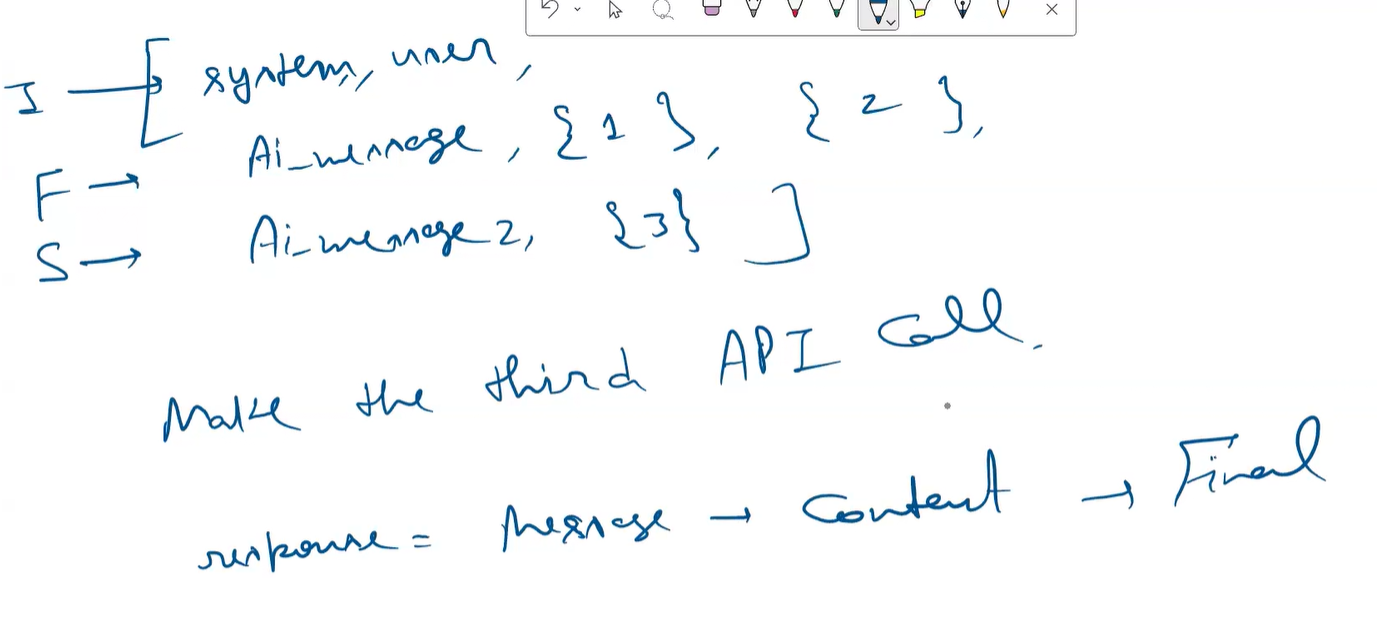

## Multiple Tools Pipeline

In [45]:
def get_result_using_tools(resume_text):
    messages = [{'role': 'system', 'content': 'Calculate the total experince from the resume based on provided tools.'},
                {'role': 'user', 'content': resume_text}]

    counter = 1
    while True:
        print(f"START: API Call {counter}")
        print(messages)
        response = client.chat.completions.create(
            model='gpt-4o-mini',
            messages=messages,
            tools=my_tools
        )

        ai_message = response.choices[0].message
        print("AI Msg")
        print(ai_message)

        if not ai_message.tool_calls:
            print('no tools calls')
            return ai_message.content
        
        messages = messages + [ai_message]
        
        tool_calls_l = ai_message.tool_calls

        for call in tool_calls_l:
            tool_name = call.function.name
            print(f"Tool Name: {tool_name}")
            tool_args = json.loads(call.function.arguments)

            if tool_name == "extract_years":
                result = extract_years(**tool_args)
            elif tool_name == "calculate_experience":
                result = calculate_experience(**tool_args)

            messages = messages + [{'role': 'tool', 'content': str(result), 'tool_call_id': call.id}]
        
        counter +=1

In [ ]:
resume_text = '''Ram worked at ABC from 2019 to 2023. After that, he joined XYZ.'''

result = get_result_using_tools(resume_text=resume_text)
print(result)

START: API Call 1
[{'role': 'system', 'content': 'Calculate the total experince from the resume based on provided tools.'}, {'role': 'user', 'content': 'Ram worked at ABC from 2019 to 2023. After that, he joined XYZ.'}]
